# Flow Hydrograph Optimization


In [1]:
from pathlib import Path
import logging
import os
import shutil

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import ras_commander
from ras_commander import (
    RasCmdr,
    RasFlowOptimization,
    init_ras_project,
    ras,
)
from ras_commander.RasUnsteady import RasUnsteady

logging.disable(logging.CRITICAL)
pd.options.display.float_format = "{:.3f}".format
print(f"ras-commander {ras_commander.__version__}")

ras-commander 0.96.2


## Development Mode

For local source testing, run this notebook with `PYTHONPATH` pointed at the repository root. The committed import cell intentionally uses normal package imports so the notebook also works for installed ras-commander users.

Repository convention keeps the import cell as Cell 0. That import cell is the only code-cell exception to the narrative rule; every workflow code section below is introduced by markdown that explains the step and why it matters.

# Flow Hydrograph Optimization

This notebook is a ras-commander companion to [HEC-RAS Tutorial 13: Flow Hydrograph Optimization](https://www.hec.usace.army.mil/confluence/rasdocs/hgt/latest/tutorials/2d-unsteady-flow/flow-hydrograph-optimization) in the HEC-RAS Guides and Tutorials, under **Tutorials > 2D Unsteady Flow > Flow Hydrograph Optimization**. The HEC tutorial describes the GUI workflow for automated flow optimization and notes that the capability was introduced in HEC-RAS Version 6.4. The project files used here are Version 6.40 files, and this notebook defaults to a local HEC-RAS 6.4.1 executable when one is available.

The notebook maps the tutorial workflow to `RasFlowOptimization`. It reads the native optimization settings, creates a copied optimization plan, computes through `RasCmdr`, and then reviews the resulting hydrograph and water-surface response. If a command-line HEC-RAS run finishes without writing native trial rows to the plan HDF or compute messages, the notebook demonstrates the ras-commander fallback pattern: scale the inflow hydrograph with `Flow Hydrograph QMult`, run candidate plans through `RasCmdr`, evaluate an HDF-derived stage objective, and compare before/after results.

The difference is important: native HEC-RAS optimization is configured in the model and iterates internally, using the GUI-oriented, bisection-style automated flow-ratio search. The fallback shown here is explicit and reproducible in Python: ras-commander runs a parameterized search over selected QMult values and applies the same engineering objective outside the GUI.

## Hydraulic Relevance

Automated flow optimization answers a common hydraulic question: **what flow magnitude produces a target stage at a location of interest?** Instead of repeatedly editing an inflow hydrograph by hand, the model is run with scaled hydrographs until the computed stage or flow matches the specified target within an engineering tolerance.

Typical applications include FEMA regulatory studies asking what discharge causes a base flood elevation at a mapped location, dam-safety and emergency-action-plan studies asking what reservoir release produces a downstream threshold stage, and design studies asking what inflow level activates a flood-control feature or overtops a critical road. In this tutorial, the target is a stage of 3963.5 ft near the Yosemite Village parking-lot low point represented by the `Yosemite Falls Vantage Point` reference location.

`QMult` is the hydraulic control used in the fallback search. A QMult value multiplies every ordinate in the selected inflow hydrograph, so the hydrograph peak and volume change proportionally while the timing and shape remain the same. That makes the search easy to audit: each trial represents the same storm hydrograph at a different flow magnitude.

## Model Overview

The example project is the HEC Tutorial 13 Merced River at Yosemite Valley 2D unsteady-flow model. It is a small demonstration model, not a floodplain-management decision model. The HEC tutorial states that the terrain was downloaded from USGS NED and resampled for the example.

Key context for the workflow:

| Item | Engineering context |
| --- | --- |
| Project | `Example_FlowOptimization`, project file `HydroFlowOptimization.prj` |
| Domain | 2D flow area named `2DArea` covering a Merced River reach in Yosemite Valley |
| Mesh | Nominal 200 ft cell generation spacing, with the geometry HDF used below for the actual cell layout |
| Simulation period | 31 Dec 1996 00:00 through 05 Jan 1997 00:00 |
| Upstream boundary | `Inflow` boundary line, using USGS streamflow from the DSS path for Merced River at Happy Isles Bridge, Yosemite CA |
| Downstream boundary | External normal-depth/friction-slope boundary named `Downstream Boundary` |
| Optimization reference | `Yosemite Falls Vantage Point`, used as the stage target location in the native settings |
| Target stage | 3963.5 ft, with a 0.1 ft tolerance |

The next map gives the H&H context before any compute work: 2D domain, mesh, upstream and downstream boundary-condition lines, and the reference area used to judge whether the parking-lot low point is kept dry.

## Workflow Coverage

| Tutorial step | ras-commander API |
| --- | --- |
| Read native optimization setup | `RasFlowOptimization.get_settings()` |
| Select scalable hydrographs | `RasFlowOptimization.list_flow_hydrographs()` |
| Enable native optimization on a copied plan | `RasFlowOptimization.copy_plan_with_optimization()` |
| Execute HEC-RAS | `RasFlowOptimization.compute_plan_and_get_trials()` / `RasCmdr.compute_plan()` |
| Fallback search if native trial output is unavailable | `RasUnsteady.update_flow_multiplier_by_station()` + `RasCmdr.compute_plan()` |
| Review results | HDF time-series extraction and plots |

The workflow keeps the original tutorial project immutable by copying it to `working/flow_hydrograph_optimization` before editing plan or unsteady-flow files.

## Configure Notebook Parameters

This cell locates the official Tutorial 13 project, defines the working folder, and records the engineering parameters used by both the native optimization setup and the fallback search. The most important values are the stage target of 3963.5 ft, the 0.1 ft tolerance, and the allowable flow-ratio range from 0.5 to 1.0 for the native optimization plan.

For local execution, set `RAS_TUTORIAL_13_PROJECT` to the extracted `Example_FlowOptimization` folder when the tutorial project is not stored under `example_projects/`. Set `RAS_EXE` only if HEC-RAS is installed somewhere other than the default 6.4.1 path.

In [2]:
def find_repo_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


def find_tutorial_project(repo_root):
    env_value = os.environ.get("RAS_TUTORIAL_13_PROJECT")
    candidates = []
    if env_value:
        candidates.append(Path(env_value).expanduser())
    candidates.append(repo_root / "example_projects" / "Example_FlowOptimization")
    for candidate in candidates:
        if (candidate / "HydroFlowOptimization.prj").exists():
            return candidate
    return candidates[0] if candidates else repo_root / "example_projects" / "Example_FlowOptimization"


REPO_ROOT = find_repo_root(Path.cwd())
TUTORIAL_13_PROJECT = find_tutorial_project(REPO_ROOT)
WORK_ROOT = REPO_ROOT / "working" / "flow_hydrograph_optimization"
TRIAL_HDF_ROOT = WORK_ROOT / "trial_hdfs"

RAS_EXE = Path(os.environ.get("RAS_EXE", "C:/Program Files (x86)/HEC/HEC-RAS/6.4.1/Ras.exe"))
RAS_VERSION = str(RAS_EXE) if RAS_EXE.exists() else os.environ.get("RAS_VERSION", "6.4.1")

BASE_PLAN = "01"
TARGET_MODE = "stage"
TARGET_REFERENCE = "Yosemite Falls Vantage Point"
TARGET_VALUE = 3963.5
TARGET_TOLERANCE = 0.1
TARGET_MIN_RATIO = 0.5
TARGET_MAX_RATIO = 1.0
TARGET_MAX_ITERATIONS = 10
TARGET_HYDROGRAPHS = ["BCLine: Inflow"]
BOUNDARY_LABEL = "Inflow"
FLOW_AREA_NAME = "2DArea"
REFERENCE_VIEW_NAME = "Parking Lot"
NOMINAL_MESH_SPACING_FT = 200
SIMULATION_PERIOD = "31 Dec 1996 00:00 to 05 Jan 1997 00:00"

RUN_NATIVE_COMPUTE = os.environ.get("RAS_RUN_NATIVE_COMPUTE", "1").lower() not in {"0", "false", "no"}
RUN_FALLBACK_SEARCH = os.environ.get("RAS_RUN_FLOW_RATIO_FALLBACK", "1").lower() not in {"0", "false", "no"}
Q_MULT_TRIALS = [1.2, 0.9, 0.6]

optimization_parameters = pd.DataFrame(
    [
        ("Target mode", TARGET_MODE, "Stage target at reference point."),
        ("Target value", f"{TARGET_VALUE:.1f} ft", "Parking-lot threshold WSE."),
        ("Tolerance", f"{TARGET_TOLERANCE:.1f} ft", "Maximum accepted WSE error."),
        ("Native min ratio", TARGET_MIN_RATIO, "Minimum native flow ratio."),
        ("Native max ratio", TARGET_MAX_RATIO, "Maximum native flow ratio."),
        ("Native max iterations", TARGET_MAX_ITERATIONS, "Native trial limit."),
        ("Fallback QMult trials", ", ".join(f"{q:.1f}" for q in Q_MULT_TRIALS), "Fallback trial multipliers."),
    ],
    columns=["parameter", "value", "engineering meaning"],
)

display(optimization_parameters)
print(f"Repository root: {REPO_ROOT}")
print(f"Tutorial project found: {(TUTORIAL_13_PROJECT / 'HydroFlowOptimization.prj').exists()}")
print(f"HEC-RAS executable/version: {RAS_VERSION}")

,parameter,value,engineering meaning
0,Target mode,stage,Stage target at reference point.
1,Target value,3963.5 ft,Parking-lot threshold WSE.
2,Tolerance,0.1 ft,Maximum accepted WSE error.
3,Native min ratio,0.500,Minimum native flow ratio.
4,Native max ratio,1.000,Maximum native flow ratio.
5,Native max iterations,10,Native trial limit.
6,Fallback QMult trials,"1.2, 0.9, 0.6",Fallback trial multipliers.


Repository root: C:\GH\symphony-workspaces\ras-commander\CLB-498
Tutorial project found: True
HEC-RAS executable/version: C:\Program Files (x86)\HEC\HEC-RAS\6.4.1\Ras.exe


## Prepare a Working Copy

The tutorial project is copied before any edits are made. The notebook updates plan and unsteady-flow files during optimization, so keeping a disposable working copy prevents accidental changes to the downloaded official example project.

In [3]:
project_file = TUTORIAL_13_PROJECT / "HydroFlowOptimization.prj"
project_available = project_file.exists()

if not project_available:
    print("Tutorial 13 project not found.")
    print(f"Expected project file: {project_file}")
    print("Set RAS_TUTORIAL_13_PROJECT to the extracted Example_FlowOptimization folder.")
    working_project = None
    ras_project = None
else:
    WORK_ROOT.mkdir(parents=True, exist_ok=True)
    working_project = WORK_ROOT / TUTORIAL_13_PROJECT.name
    if working_project.exists():
        shutil.rmtree(working_project)
    if TRIAL_HDF_ROOT.exists():
        shutil.rmtree(TRIAL_HDF_ROOT)
    TRIAL_HDF_ROOT.mkdir(parents=True, exist_ok=True)

    shutil.copytree(TUTORIAL_13_PROJECT, working_project)
    ras_project = init_ras_project(working_project, RAS_VERSION)

    display(ras_project.plan_df[["plan_number", "Plan Title", "Short Identifier"]])
    print(f"Working project: {working_project}")

,plan_number,Plan Title,Short Identifier
0,01,Base,Base


Working project: C:\GH\symphony-workspaces\ras-commander\CLB-498\working\flow_hydrograph_optimization\Example_FlowOptimization


## Plan-View Model Context

This map is an engineering orientation figure, not a compute result. It reads the geometry HDF and RAS Mapper named view to show the 2D mesh, the upstream Happy Isles DSS inflow boundary, the downstream normal-depth boundary, and the parking-lot reference area used by the tutorial. The right panel zooms to the hydraulically relevant area instead of leaving the reader to infer the target location from a full-domain plot.

2D flow area                                                          2DArea
geometry cells                                                          2724
nominal mesh spacing ft                                                  200
simulation period                     31 Dec 1996 00:00 to 05 Jan 1997 00:00
inflow source              USGS streamflow DSS, Merced River at Happy Isl...
reference location                              Yosemite Falls Vantage Point
Name: model_overview, dtype: object

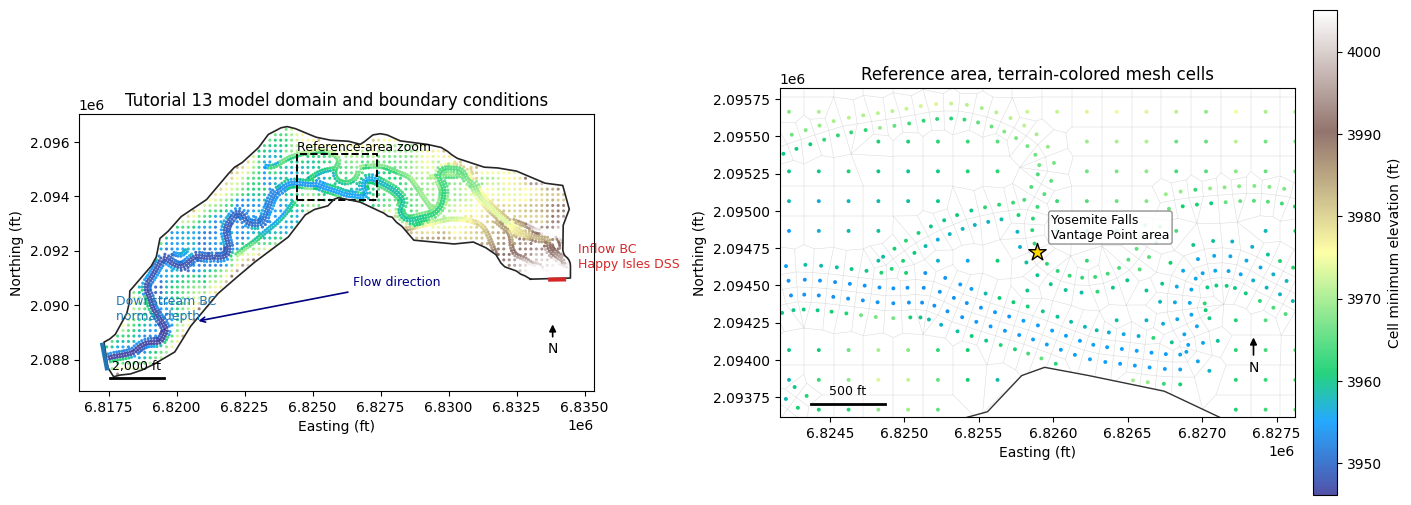

In [4]:
def _decode_text(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore").strip()
    return str(value).strip()


def read_named_view(rasmap_path, view_name):
    import xml.etree.ElementTree as ET

    root = ET.parse(rasmap_path).getroot()
    for node in root.findall(".//NamedView"):
        if node.attrib.get("Name") == view_name:
            return {
                "min_x": float(node.attrib["MinX"]),
                "max_x": float(node.attrib["MaxX"]),
                "min_y": float(node.attrib["MinY"]),
                "max_y": float(node.attrib["MaxY"]),
            }
    return None


def read_plan_view_geometry(geometry_hdf_path, rasmap_path):
    with h5py.File(geometry_hdf_path, "r") as hdf:
        area_path = f"Geometry/2D Flow Areas/{FLOW_AREA_NAME}"
        centers = hdf[f"{area_path}/Cells Center Coordinate"][()]
        min_elev = hdf[f"{area_path}/Cells Minimum Elevation"][()]
        face_points = hdf[f"{area_path}/FacePoints Coordinate"][()]
        face_indexes = hdf[f"{area_path}/Faces FacePoint Indexes"][()]
        domain_points = hdf["Geometry/2D Flow Areas/Polygon Points"][()]
        bc_attrs = hdf["Geometry/Boundary Condition Lines/Attributes"][()]
        bc_info = hdf["Geometry/Boundary Condition Lines/Polyline Info"][()]
        bc_points = hdf["Geometry/Boundary Condition Lines/Polyline Points"][()]

    boundary_lines = []
    for attr, info in zip(bc_attrs, bc_info):
        start = int(info[0])
        count = int(info[1])
        boundary_lines.append(
            {
                "name": _decode_text(attr["Name"]),
                "type": _decode_text(attr["Type"]),
                "points": bc_points[start : start + count],
            }
        )

    return {
        "centers": centers,
        "min_elev": min_elev,
        "mesh_segments": face_points[face_indexes],
        "domain_points": domain_points,
        "boundary_lines": boundary_lines,
        "named_view": read_named_view(rasmap_path, REFERENCE_VIEW_NAME),
    }


def add_scale_bar(ax, length_ft, label):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    x = x0 + 0.06 * (x1 - x0)
    y = y0 + 0.04 * (y1 - y0)
    ax.plot([x, x + length_ft], [y, y], color="black", linewidth=2.0)
    ax.text(x + length_ft / 2, y + 0.018 * (y1 - y0), label, ha="center", va="bottom", fontsize=9)


def add_north_arrow(ax):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    x = x0 + 0.92 * (x1 - x0)
    y = y0 + 0.15 * (y1 - y0)
    ax.annotate(
        "N",
        xy=(x, y + 0.10 * (y1 - y0)),
        xytext=(x, y),
        ha="center",
        va="center",
        fontsize=10,
        arrowprops={"arrowstyle": "-|>", "linewidth": 1.2, "color": "black"},
    )


model_geometry = None
REFERENCE_SEARCH_EXTENT = None

if project_available:
    from matplotlib.collections import LineCollection
    from matplotlib.patches import Rectangle

    geometry_hdf = working_project / f"{ras_project.project_name}.g01.hdf"
    rasmap_path = working_project / f"{ras_project.project_name}.rasmap"
    model_geometry = read_plan_view_geometry(geometry_hdf, rasmap_path)
    REFERENCE_SEARCH_EXTENT = model_geometry["named_view"]

    centers = model_geometry["centers"]
    domain_points = model_geometry["domain_points"]
    named_view = model_geometry["named_view"]
    reference_xy = None
    if named_view:
        reference_xy = (
            (named_view["min_x"] + named_view["max_x"]) / 2,
            (named_view["min_y"] + named_view["max_y"]) / 2,
        )

    overview = pd.Series(
        {
            "2D flow area": FLOW_AREA_NAME,
            "geometry cells": len(centers),
            "nominal mesh spacing ft": NOMINAL_MESH_SPACING_FT,
            "simulation period": SIMULATION_PERIOD,
            "inflow source": "USGS streamflow DSS, Merced River at Happy Isles Bridge",
            "reference location": TARGET_REFERENCE,
        },
        name="model_overview",
    )
    display(overview)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    elevation_limits = np.nanpercentile(model_geometry["min_elev"], [2, 98])

    scatter = axes[0].scatter(
        centers[:, 0],
        centers[:, 1],
        c=model_geometry["min_elev"],
        s=5,
        cmap="terrain",
        vmin=elevation_limits[0],
        vmax=elevation_limits[1],
        linewidths=0,
        alpha=0.85,
    )
    axes[0].plot(domain_points[:, 0], domain_points[:, 1], color="0.15", linewidth=1.2, label="2D flow area")
    for line in model_geometry["boundary_lines"]:
        xy = line["points"]
        color = "tab:red" if line["name"] == BOUNDARY_LABEL else "tab:blue"
        axes[0].plot(xy[:, 0], xy[:, 1], color=color, linewidth=3.0)
        midpoint = xy[len(xy) // 2]
        if line["name"] == BOUNDARY_LABEL:
            label = "Inflow BC\nHappy Isles DSS"
            offset = (10, 8)
        else:
            label = "Downstream BC\nnormal depth"
            offset = (10, 18)
        axes[0].annotate(label, midpoint, xytext=offset, textcoords="offset points", fontsize=9, color=color)

    if named_view:
        rect = Rectangle(
            (named_view["min_x"], named_view["min_y"]),
            named_view["max_x"] - named_view["min_x"],
            named_view["max_y"] - named_view["min_y"],
            fill=False,
            edgecolor="black",
            linewidth=1.4,
            linestyle="--",
        )
        axes[0].add_patch(rect)
        axes[0].text(named_view["min_x"], named_view["max_y"], "Reference-area zoom", fontsize=9, va="bottom")

    axes[0].annotate(
        "Flow direction",
        xy=(6820700, 2089400),
        xytext=(6826500, 2090700),
        arrowprops={"arrowstyle": "->", "linewidth": 1.2, "color": "navy"},
        color="navy",
        fontsize=9,
    )
    axes[0].set_title("Tutorial 13 model domain and boundary conditions")
    axes[0].set_xlabel("Easting (ft)")
    axes[0].set_ylabel("Northing (ft)")
    axes[0].set_aspect("equal", adjustable="box")
    add_scale_bar(axes[0], 2000, "2,000 ft")
    add_north_arrow(axes[0])

    zoom_ax = axes[1]
    mesh_collection = LineCollection(model_geometry["mesh_segments"], colors="0.72", linewidths=0.35, alpha=0.55)
    zoom_ax.add_collection(mesh_collection)
    zoom_ax.scatter(
        centers[:, 0],
        centers[:, 1],
        c=model_geometry["min_elev"],
        s=8,
        cmap="terrain",
        vmin=elevation_limits[0],
        vmax=elevation_limits[1],
        linewidths=0,
        alpha=0.95,
    )
    zoom_ax.plot(domain_points[:, 0], domain_points[:, 1], color="0.2", linewidth=1.0)
    if reference_xy:
        zoom_ax.scatter([reference_xy[0]], [reference_xy[1]], marker="*", s=170, color="gold", edgecolor="black", zorder=5)
        zoom_ax.annotate(
            "Yosemite Falls\nVantage Point area",
            reference_xy,
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "0.5", "alpha": 0.85},
        )
    if named_view:
        pad = 250
        zoom_ax.set_xlim(named_view["min_x"] - pad, named_view["max_x"] + pad)
        zoom_ax.set_ylim(named_view["min_y"] - pad, named_view["max_y"] + pad)
    zoom_ax.set_title("Reference area, terrain-colored mesh cells")
    zoom_ax.set_xlabel("Easting (ft)")
    zoom_ax.set_ylabel("Northing (ft)")
    zoom_ax.set_aspect("equal", adjustable="box")
    add_scale_bar(zoom_ax, 500, "500 ft")
    add_north_arrow(zoom_ax)

    colorbar = fig.colorbar(scatter, ax=axes, shrink=0.82, pad=0.01)
    colorbar.set_label("Cell minimum elevation (ft)")
    plt.show()
elif not project_available:
    print("Skipping plan-view figure because the Tutorial 13 project is unavailable.")

## Inspect Native Optimization Settings

Before changing the model, read the optimization settings already stored in the base plan. This is the file-based equivalent of opening the HEC-RAS Automated Flow Optimization dialog and checking the reference location, target value, tolerance, and selected hydrograph. Listing hydrographs also confirms that the `BCLine: Inflow` boundary can be scaled.

In [5]:
if project_available:
    settings = RasFlowOptimization.get_settings(BASE_PLAN, ras_object=ras_project)
    settings_preview = pd.Series(
        {k: v for k, v in settings.items() if k not in {"raw_values", "plan_path"}},
        name="native_settings",
    )
    display(settings_preview)

    hydrographs = RasFlowOptimization.list_flow_hydrographs(BASE_PLAN, ras_object=ras_project)
    hydrograph_review_cols = [
        "optimization_hydrograph",
        "flow_area",
        "bc_line",
        "bc_type",
        "interval",
        "use_dss",
        "dss_file",
    ]
    display(hydrographs[[col for col in hydrograph_review_cols if col in hydrographs.columns]])
    if not hydrographs.empty and "dss_path" in hydrographs.columns:
        print("Selected inflow DSS path:")
        print(str(hydrographs.iloc[0]["dss_path"]))
else:
    settings = None
    hydrographs = pd.DataFrame()

enabled                                                         True
mode                                                           stage
reference                    Ref Point: Yosemite Falls Vantage Point
reference_type                                             Ref Point
reference_location                      Yosemite Falls Vantage Point
target_value                                                3963.500
tolerance                                                      0.100
initial_ratio                                                  1.000
min_ratio                                                      0.500
max_ratio                                                      1.000
max_iterations                                                    10
user_selected_hydrographs                                       True
hydrographs                                         [BCLine: Inflow]
restart_approach                                                None
transition_period_hours           

,optimization_hydrograph,flow_area,bc_line,bc_type,interval,use_dss,dss_file
0,BCLine: Inflow,2DArea,Inflow,Flow Hydrograph,1HOUR,True,.\Flow_Data\streamflow.dss


Selected inflow DSS path:
/MERCED R A HAPPY ISLES BRIDGE/YOSEMITE CA/FLOW/01DEC1996-01JAN1997/15MIN/USGS/


## Configure a Native Optimization Plan

The native plan setup mirrors the HEC tutorial: stage mode, reference point `Yosemite Falls Vantage Point`, target stage 3963.5 ft, and 0.1 ft tolerance. The min and max ratios bound the native HEC-RAS search so it cannot scale the selected inflow below 50 percent or above 100 percent of the starting hydrograph. The maximum-iteration value limits the number of native trial simulations.

In [6]:
if project_available:
    optimization_plan = RasFlowOptimization.copy_plan_with_optimization(
        BASE_PLAN,
        new_plan_shortid="Native Flow Opt",
        new_title="Native Flow Optimization",
        mode=TARGET_MODE,
        reference_location=TARGET_REFERENCE,
        target_value=TARGET_VALUE,
        tolerance=TARGET_TOLERANCE,
        hydrographs=TARGET_HYDROGRAPHS,
        min_ratio=TARGET_MIN_RATIO,
        max_ratio=TARGET_MAX_RATIO,
        max_iterations=TARGET_MAX_ITERATIONS,
        ras_object=ras_project,
    )
    print(f"Created optimization plan: {optimization_plan}")
    display(pd.Series(RasFlowOptimization.get_settings(optimization_plan, ras_object=ras_project)).drop("raw_values"))
else:
    optimization_plan = None

Created optimization plan: 02


enabled                                                                   True
mode                                                                     stage
reference                              Ref Point: Yosemite Falls Vantage Point
reference_type                                                       Ref Point
reference_location                                Yosemite Falls Vantage Point
target_value                                                          3963.500
tolerance                                                                0.100
initial_ratio                                                            1.000
min_ratio                                                                0.500
max_ratio                                                                1.000
max_iterations                                                              10
user_selected_hydrographs                                                 True
hydrographs                                         

## Execute the Native Optimization Plan

This cell computes the copied native optimization plan through `RasCmdr`. If HEC-RAS writes flow-optimization trial rows to the plan HDF or compute messages, `RasFlowOptimization.compute_plan_and_get_trials()` returns them for review. On some command-line runs, HEC-RAS completes the plan but does not expose the GUI trial table in machine-readable output; when that happens, the following fallback section performs an explicit QMult search.

In [7]:
native_result = None
native_trials = pd.DataFrame()

if project_available and RUN_NATIVE_COMPUTE:
    native_result = RasFlowOptimization.compute_plan_and_get_trials(
        optimization_plan,
        ras_object=ras_project,
        num_cores=4,
        verify=True,
        force_rerun=True,
    )
    print(native_result["compute_result"])
    native_trials = native_result["trial_results"]

    if native_trials.empty:
        print(
            "Native HEC-RAS command-line compute completed, but no native flow "
            "optimization trial rows were written to the plan HDF or compute messages. "
            "The next section falls back to a ras-commander search over the inflow QMult."
        )
    else:
        display(native_trials)
elif project_available:
    print("RUN_NATIVE_COMPUTE is disabled. Skipping native HEC-RAS execution.")

ComputeResult(SUCCESS, results_df_row=available)
Native HEC-RAS command-line compute completed, but no native flow optimization trial rows were written to the plan HDF or compute messages. The next section falls back to a ras-commander search over the inflow QMult.


## Define HDF Extraction Helpers

The plots and objective calculation use HDF results produced by HEC-RAS. These helpers keep the extraction logic in one place: read the DSS-linked inflow hydrograph written to the plan HDF, read water-surface elevation for a target 2D cell, calculate the maximum WSE by cell, and assemble one metrics row per QMult trial.

In [8]:
def _as_text(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore").strip()
    return str(value).strip()


def plan_hdf_path(plan_number):
    return working_project / f"{ras_project.project_name}.p{str(plan_number).zfill(2)}.hdf"


def read_inflow_hydrograph(hdf_path):
    dataset_path = (
        "Event Conditions/Unsteady/Boundary Conditions/Flow Hydrographs/"
        f"2D: {FLOW_AREA_NAME} BCLine: {BOUNDARY_LABEL}"
    )
    with h5py.File(hdf_path, "r") as hdf:
        data = hdf[dataset_path][()]
    return pd.DataFrame({"days": data[:, 0], "flow_cfs": data[:, 1]})


def read_reference_wse(hdf_path, cell_index):
    base = "Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series"
    with h5py.File(hdf_path, "r") as hdf:
        time_days = hdf[f"{base}/Time"][()]
        wse = hdf[f"{base}/2D Flow Areas/{FLOW_AREA_NAME}/Water Surface"][:, cell_index]
    wse = np.where(wse < -1e20, np.nan, wse)
    return pd.DataFrame({"days": time_days, "wse_ft": wse})


def max_wse_by_cell(hdf_path):
    path = (
        "Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series/"
        f"2D Flow Areas/{FLOW_AREA_NAME}/Water Surface"
    )
    with h5py.File(hdf_path, "r") as hdf:
        data = hdf[path][()]
    data = np.where(data < -1e20, np.nan, data)
    return np.nanmax(data, axis=0)


def _inside_extent(points, extent):
    if extent is None:
        return np.ones(len(points), dtype=bool)
    return (
        (points[:, 0] >= extent["min_x"])
        & (points[:, 0] <= extent["max_x"])
        & (points[:, 1] >= extent["min_y"])
        & (points[:, 1] <= extent["max_y"])
    )


def find_reference_cell(geometry_hdf, baseline_hdf, target_value, tolerance, search_extent=None):
    with h5py.File(geometry_hdf, "r") as hdf:
        centers = hdf[f"Geometry/2D Flow Areas/{FLOW_AREA_NAME}/Cells Center Coordinate"][()]
        min_elev = hdf[f"Geometry/2D Flow Areas/{FLOW_AREA_NAME}/Cells Minimum Elevation"][()]

    baseline_max = max_wse_by_cell(baseline_hdf)
    finite = np.isfinite(baseline_max) & np.isfinite(min_elev)
    target_like = finite & (np.abs(min_elev - target_value) <= 0.15)
    wet_at_baseline = baseline_max > target_value + tolerance
    in_reference_area = _inside_extent(centers, search_extent)

    candidates = np.where(target_like & wet_at_baseline & in_reference_area)[0]
    if len(candidates) == 0:
        candidates = np.where(target_like & wet_at_baseline)[0]
    if len(candidates) == 0:
        candidates = np.where(finite & in_reference_area)[0]
    if len(candidates) == 0:
        candidates = np.where(finite)[0]

    best = min(
        candidates,
        key=lambda idx: (
            abs(float(min_elev[idx]) - target_value),
            abs(float(baseline_max[idx]) - target_value),
        ),
    )
    return {
        "cell_index": int(best),
        "x": float(centers[best, 0]),
        "y": float(centers[best, 1]),
        "min_elevation_ft": float(min_elev[best]),
        "baseline_max_wse_ft": float(baseline_max[best]),
    }


def trial_metrics_from_hdfs(trial_hdfs, reference_cell):
    rows = []
    for trial, (qmult, hdf_path) in enumerate(trial_hdfs.items(), start=1):
        max_wse = max_wse_by_cell(hdf_path)[reference_cell["cell_index"]]
        difference = float(max_wse - TARGET_VALUE)
        rows.append(
            {
                "trial": trial,
                "qmult": qmult,
                "hydrograph_scale_vs_base": qmult / Q_MULT_TRIALS[0],
                "computed_wse_ft": float(max_wse),
                "target_wse_ft": TARGET_VALUE,
                "difference_ft": difference,
                "objective_ft": abs(difference),
                "within_tolerance": abs(difference) <= TARGET_TOLERANCE,
                "hdf_path": str(hdf_path),
            }
        )
    return pd.DataFrame(rows)

## Fallback: ras-commander Flow Multiplier Search

The native settings remain on the copied plan. The fallback below demonstrates the same calibration/search pattern used by `RasCalibrate`: update a model parameter, run HEC-RAS through `RasCmdr`, calculate an objective from the result HDF, and select the best run.

Here the parameter is the inflow `Flow Hydrograph QMult` in the unsteady-flow file. The starting trial uses QMult 1.2, which represents the input hydrograph already stored in the downloaded tutorial file. QMult 0.9 scales every inflow ordinate to 75 percent of that starting trial, and QMult 0.6 scales every inflow ordinate to 50 percent of that starting trial. This does not change the hydrograph timing; it changes only the magnitude and volume.

In [9]:
fallback_trials = pd.DataFrame()
reference_cell = None
best_trial = None
trial_hdfs = {}

if project_available and RUN_FALLBACK_SEARCH and native_trials.empty:
    unsteady_file = working_project / f"{ras_project.project_name}.u01"

    for qmult in Q_MULT_TRIALS:
        RasUnsteady.update_flow_multiplier_by_station(
            unsteady_file,
            BOUNDARY_LABEL,
            qmult,
            ras_object=ras_project,
        )
        compute_result = RasCmdr.compute_plan(
            BASE_PLAN,
            ras_object=ras_project,
            num_cores=4,
            verify=True,
            force_rerun=True,
        )
        assert compute_result, f"HEC-RAS compute failed for QMult={qmult}"

        source_hdf = plan_hdf_path(BASE_PLAN)
        snapshot_hdf = TRIAL_HDF_ROOT / f"qmult_{qmult:.3f}.p{BASE_PLAN}.hdf"
        shutil.copy2(source_hdf, snapshot_hdf)
        trial_hdfs[qmult] = snapshot_hdf

    geometry_hdf = working_project / f"{ras_project.project_name}.g01.hdf"
    reference_cell = find_reference_cell(
        geometry_hdf,
        trial_hdfs[Q_MULT_TRIALS[0]],
        TARGET_VALUE,
        TARGET_TOLERANCE,
        search_extent=REFERENCE_SEARCH_EXTENT,
    )
    fallback_trials = trial_metrics_from_hdfs(trial_hdfs, reference_cell)
    fallback_trials["result"] = np.select(
        [
            fallback_trials["difference_ft"] > TARGET_TOLERANCE,
            fallback_trials["within_tolerance"],
        ],
        [
            "Reject: overshoots.",
            "Accept: in tolerance.",
        ],
        default="Reject: below target.",
    )
    best_trial = fallback_trials.sort_values(
        ["within_tolerance", "objective_ft", "qmult"],
        ascending=[False, True, False],
    ).iloc[0]

    display(pd.Series(reference_cell, name="reference_cell"))
    fallback_review = fallback_trials.drop(columns=["hdf_path"])
    display(fallback_review)
    print(
        "Selected QMult "
        f"{best_trial['qmult']:.3f}; max WSE {best_trial['computed_wse_ft']:.3f} ft "
        f"vs target {TARGET_VALUE:.3f} ft."
    )
elif project_available and not native_trials.empty:
    print("Native trial results were available; fallback search was not needed.")
elif project_available:
    print("Fallback search is disabled.")

cell_index               1622.000
x                     6826195.033
y                     2094552.026
min_elevation_ft         3963.517
baseline_max_wse_ft      3968.704
Name: reference_cell, dtype: float64

,trial,qmult,hydrograph_scale_vs_base,computed_wse_ft,target_wse_ft,difference_ft,objective_ft,within_tolerance,result
0,1,1.200,1.000,3968.704,3963.500,5.204,5.204,False,Reject: overshoots.
1,2,0.900,0.750,3963.517,3963.500,0.017,0.017,True,Accept: in tolerance.
2,3,0.600,0.500,3963.517,3963.500,0.017,0.017,True,Accept: in tolerance.


Selected QMult 0.900; max WSE 3963.517 ft vs target 3963.500 ft.


## Input vs Optimized Hydrograph

This plot checks the input side of the optimization. Because QMult multiplies every DSS inflow ordinate, the optimized hydrograph should keep the same shape and timing while reducing peak flow and volume in proportion to the selected multiplier. The table reports peak flow and a simple volume proxy so the flow scaling is visible without reading the unsteady-flow file.

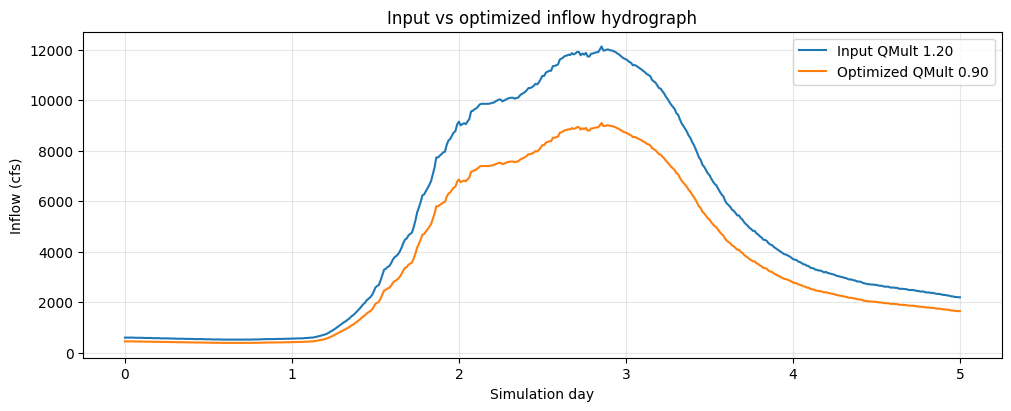

,metric,input,optimized,optimized/input
0,peak flow cfs,12120.000,9090.000,0.750
1,volume proxy cfs-days,24975.387,18731.541,0.750


In [10]:
if project_available and not fallback_trials.empty:
    baseline_hydrograph = read_inflow_hydrograph(trial_hdfs[Q_MULT_TRIALS[0]])
    optimized_hydrograph = read_inflow_hydrograph(Path(best_trial["hdf_path"]))

    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.plot(baseline_hydrograph["days"], baseline_hydrograph["flow_cfs"], label=f"Input QMult {Q_MULT_TRIALS[0]:.2f}")
    ax.plot(optimized_hydrograph["days"], optimized_hydrograph["flow_cfs"], label=f"Optimized QMult {best_trial['qmult']:.2f}")
    ax.set_xlabel("Simulation day")
    ax.set_ylabel("Inflow (cfs)")
    ax.set_title("Input vs optimized inflow hydrograph")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    comparison = pd.DataFrame(
        {
            "metric": ["peak flow cfs", "volume proxy cfs-days"],
            "input": [
                baseline_hydrograph["flow_cfs"].max(),
                np.trapezoid(baseline_hydrograph["flow_cfs"], baseline_hydrograph["days"]),
            ],
            "optimized": [
                optimized_hydrograph["flow_cfs"].max(),
                np.trapezoid(optimized_hydrograph["flow_cfs"], optimized_hydrograph["days"]),
            ],
        }
    )
    comparison["optimized/input"] = comparison["optimized"] / comparison["input"]
    display(comparison)

## Objective Function Convergence

The fallback objective is the absolute error between computed maximum WSE at the reference cell and the 3963.5 ft target stage. In the expected Tutorial 13 run, QMult 1.2 overshoots the target by several feet at the reference-area cell, so it is rejected. QMult 0.9 meets the 0.1 ft tolerance. QMult 0.6 can show the same WSE error because both lower-flow trials are below the local wetting/terrain threshold at the selected target cell; the matching stage is therefore a hydraulic threshold effect, not proof that the much smaller hydrograph is equally representative.

When multiple trials are inside tolerance with the same objective, the notebook selects the highest QMult. That preference keeps the optimized hydrograph as close as possible to the original inflow while still meeting the stage constraint.

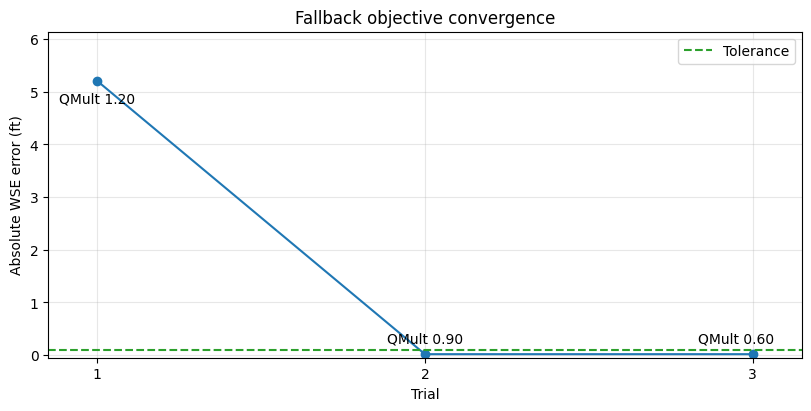

,trial,qmult,computed_wse_ft,target_wse_ft,difference_ft,objective_ft,within_tolerance,result
0,1,1.200,3968.704,3963.500,5.204,5.204,False,Reject: overshoots.
1,2,0.900,3963.517,3963.500,0.017,0.017,True,Accept: in tolerance.
2,3,0.600,3963.517,3963.500,0.017,0.017,True,Accept: in tolerance.


In [11]:
if project_available and not fallback_trials.empty:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(fallback_trials["trial"], fallback_trials["objective_ft"], marker="o")
    ax.axhline(TARGET_TOLERANCE, color="tab:green", linestyle="--", label="Tolerance")
    ax.set_xlim(fallback_trials["trial"].min() - 0.15, fallback_trials["trial"].max() + 0.15)
    ax.set_ylim(bottom=-0.05, top=max(fallback_trials["objective_ft"].max() * 1.18, TARGET_TOLERANCE * 2))
    for _, row in fallback_trials.iterrows():
        x_offset = -12 if row["trial"] == fallback_trials["trial"].max() else 0
        y_offset = -16 if row["objective_ft"] > fallback_trials["objective_ft"].max() * 0.85 else 8
        ax.annotate(
            f"QMult {row['qmult']:.2f}",
            (row["trial"], row["objective_ft"]),
            textcoords="offset points",
            xytext=(x_offset, y_offset),
            ha="center",
        )
    ax.set_xticks(fallback_trials["trial"])
    ax.set_xlabel("Trial")
    ax.set_ylabel("Absolute WSE error (ft)")
    ax.set_title("Fallback objective convergence")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    display(
        fallback_trials[
            [
                "trial",
                "qmult",
                "computed_wse_ft",
                "target_wse_ft",
                "difference_ft",
                "objective_ft",
                "within_tolerance",
                "result",
            ]
        ]
    )

## Before/After WSE Comparison

The final comparison checks the hydraulic response rather than only the input hydrograph. The time-series panel shows whether the selected QMult keeps the reference-cell WSE near the target throughout the event, and the residual panel shows the maximum-stage error before and after optimization. A successful run should move the maximum WSE from above the target to within the green tolerance band.

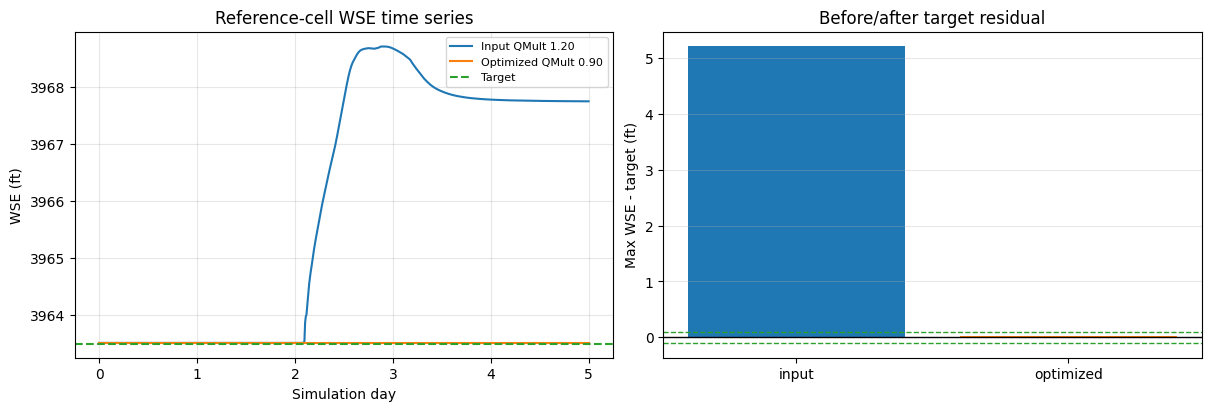

,run,max_wse_ft,difference_from_target_ft
0,input,3968.704,5.204
1,optimized,3963.517,0.017


Executed flow hydrograph optimization workflow with before/after WSE comparison.


In [12]:
if project_available and not fallback_trials.empty:
    baseline_wse = read_reference_wse(trial_hdfs[Q_MULT_TRIALS[0]], reference_cell["cell_index"])
    optimized_wse = read_reference_wse(Path(best_trial["hdf_path"]), reference_cell["cell_index"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].plot(baseline_wse["days"], baseline_wse["wse_ft"], label=f"Input QMult {Q_MULT_TRIALS[0]:.2f}")
    axes[0].plot(optimized_wse["days"], optimized_wse["wse_ft"], label=f"Optimized QMult {best_trial['qmult']:.2f}")
    axes[0].axhline(TARGET_VALUE, color="tab:green", linestyle="--", label="Target")
    axes[0].set_xlabel("Simulation day")
    axes[0].set_ylabel("WSE (ft)")
    axes[0].set_title("Reference-cell WSE time series")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    before_after = pd.DataFrame(
        {
            "run": ["input", "optimized"],
            "max_wse_ft": [baseline_wse["wse_ft"].max(), optimized_wse["wse_ft"].max()],
        }
    )
    before_after["difference_from_target_ft"] = before_after["max_wse_ft"] - TARGET_VALUE
    axes[1].bar(before_after["run"], before_after["difference_from_target_ft"], color=["tab:blue", "tab:orange"])
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].axhline(TARGET_TOLERANCE, color="tab:green", linestyle="--", linewidth=1)
    axes[1].axhline(-TARGET_TOLERANCE, color="tab:green", linestyle="--", linewidth=1)
    axes[1].set_ylabel("Max WSE - target (ft)")
    axes[1].set_title("Before/after target residual")
    axes[1].grid(True, axis="y", alpha=0.3)
    plt.show()

    display(before_after)

    assert best_trial["objective_ft"] <= TARGET_TOLERANCE
    print("Executed flow hydrograph optimization workflow with before/after WSE comparison.")